In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/Users/lokesh/Downloads/bike_sharing.csv")

In [5]:
df.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [7]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

#We can see there are no missing values; hence no need to treat NULL values.

In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10881    False
10882    False
10883    False
10884    False
10885    False
Length: 10886, dtype: bool

In [9]:
df['holiday'].unique()

array([0, 1])

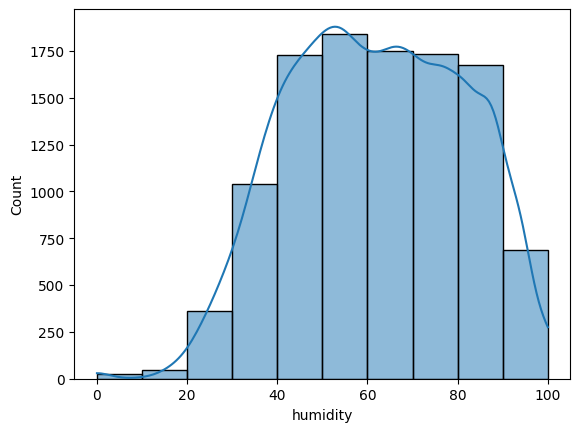

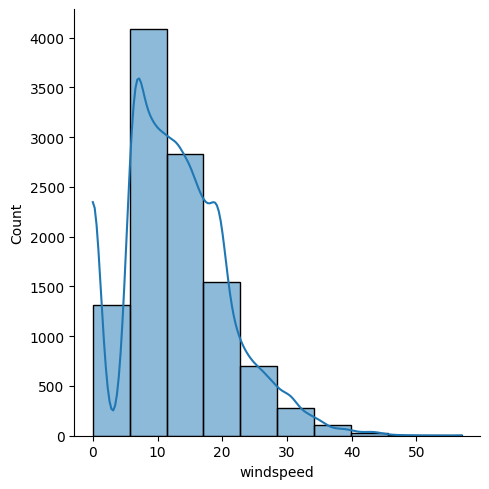

In [10]:
# Count plot and dist plot
sns.histplot(df['humidity'],bins=10,kde=True)
sns.displot(df['windspeed'],bins=10,kde=True)

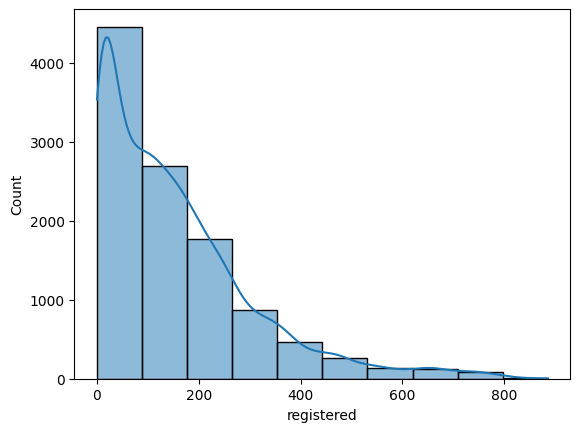

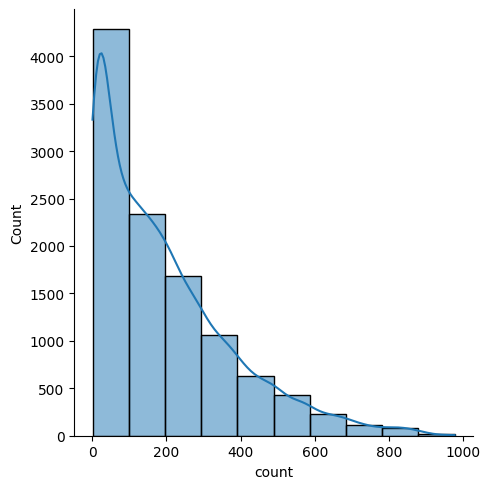

In [11]:
sns.histplot(df['registered'],bins=10,kde=True)
sns.displot(df['count'],bins=10,kde=True)

In [12]:
df["registered"].max()

np.int64(886)

<Axes: >

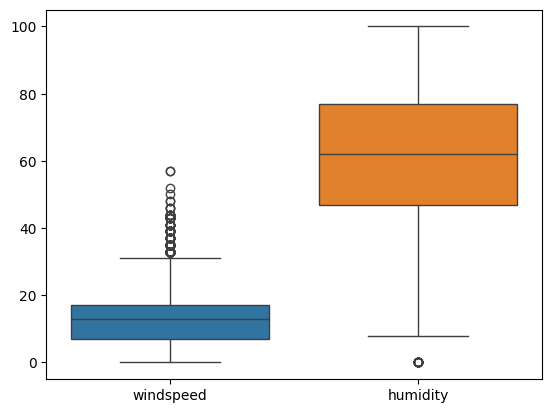

In [13]:
sns.boxplot(df[['windspeed','humidity']])

<Axes: >

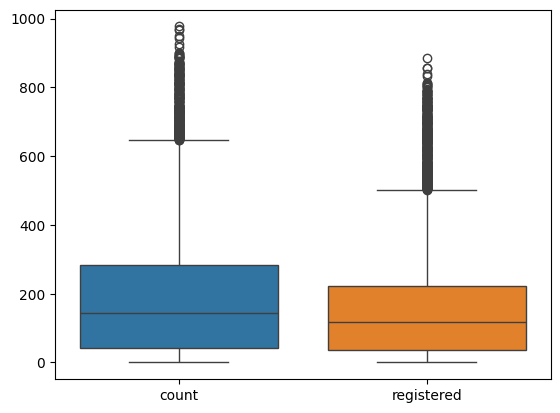

In [14]:

sns.boxplot(df[['count','registered']])

We can see huge number of outliers in count and registered column of the dataset but removing is not advised untill client confirmation.

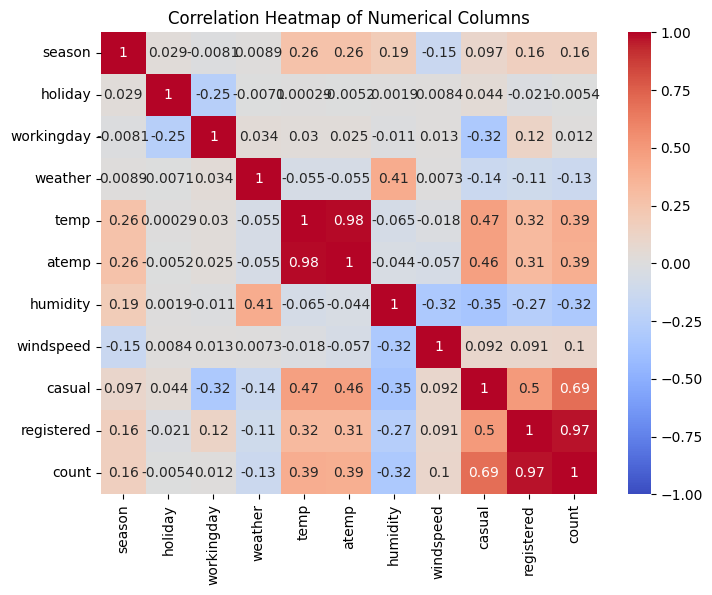

In [15]:
# Step 1: Select numerical columns (exclude datetime)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_data = df[numerical_cols]

# Step 2: Compute the correlation matrix
corr_matrix = numerical_data.corr()

# Step 3: Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

Average Rentals by Temperature Range:
         temp_bin     casual  registered       count
0   cold (0-15°C)   9.770704  100.278220  110.048924
1  warm (15-25°C)  33.858824  157.556946  191.415770
2   hot (25-35°C)  62.588200  204.624206  267.212405


/var/folders/dn/m_4rkjfx6wjc1smxgxdlfl6m0000gn/T/ipykernel_41820/725723076.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rentals = df.groupby('temp_bin')[['casual', 'registered', 'count']].mean().reset_index()


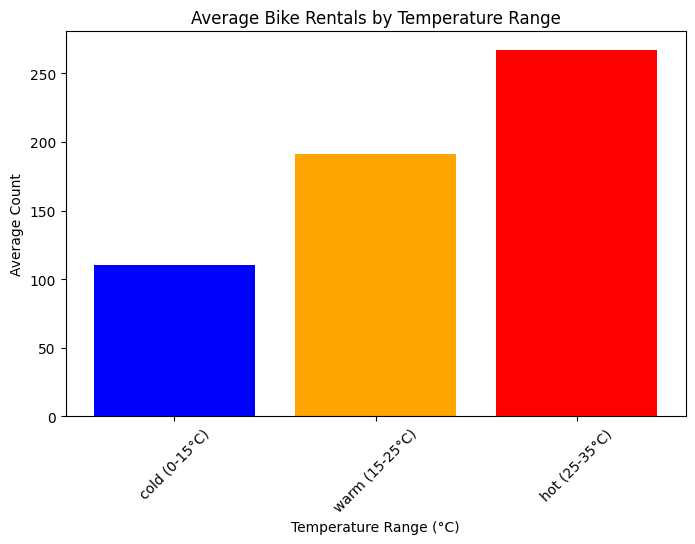

In [16]:
# Define custom temperature ranges
bins = [0, 15, 25, 35]  # Temperature ranges: 0-15°C, 15-25°C, 25-35°C
labels = ['cold (0-15°C)', 'warm (15-25°C)', 'hot (25-35°C)']
df['temp_bin'] = pd.cut(df['temp'], bins=bins, labels=labels, include_lowest=True)

# Calculate average rentals per temperature bin
avg_rentals = df.groupby('temp_bin')[['casual', 'registered', 'count']].mean().reset_index()

# Display results
print("Average Rentals by Temperature Range:")
print(avg_rentals)

# Visualize the results
plt.figure(figsize=(8, 5))
plt.bar(avg_rentals['temp_bin'], avg_rentals['count'], color=['blue', 'orange', 'red'])
plt.title('Average Bike Rentals by Temperature Range')
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.show()

The temperature positive coorelation with casual, count and registered is well defined and indicates more movements and rentals of bikes under increasing temperatures mainly from cold to warm and finally hot.

Average Rentals by Hour Range:
            hour_bin     casual  registered       count
0        Night (0-6)   4.539866   20.637854   25.177720
1     Morning (6-12)  28.955678  180.993040  209.948718
2  Afternoon (12-18)  74.338816  225.190424  299.529240
3    Evening (18-24)  35.639620  192.879020  228.518640


/var/folders/dn/m_4rkjfx6wjc1smxgxdlfl6m0000gn/T/ipykernel_41820/3469640075.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rentals = df.groupby('hour_bin')[['casual', 'registered', 'count']].mean().reset_index()


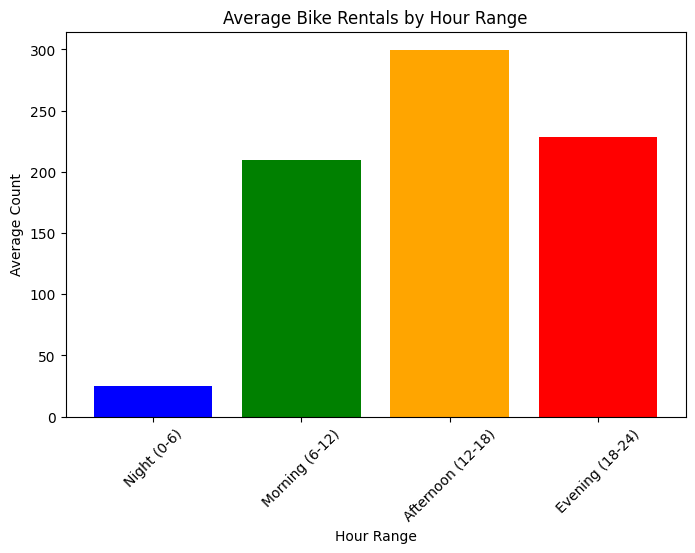

In [17]:
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract hour from datetime
df['hour'] = df['datetime'].dt.hour

# Define custom hour ranges
bins = [0, 6, 12, 18, 24]  # Hour ranges: 0-6, 6-12, 12-18, 18-24
labels = ['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-18)', 'Evening (18-24)']
df['hour_bin'] = pd.cut(df['hour'], bins=bins, labels=labels, include_lowest=True, right=False)

# Calculate average rentals per hour bin
avg_rentals = df.groupby('hour_bin')[['casual', 'registered', 'count']].mean().reset_index()

# Display results
print("Average Rentals by Hour Range:")
print(avg_rentals)

# Visualize the results
plt.figure(figsize=(8, 5))
plt.bar(avg_rentals['hour_bin'], avg_rentals['count'], color=['blue', 'green', 'orange', 'red'])
plt.title('Average Bike Rentals by Hour Range')
plt.xlabel('Hour Range')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.show()

Average Rentals by Month:
   month_bin     casual  registered       count
0        Jan   8.203620   82.162896   90.366516
1        Feb  10.318535   99.684795  110.003330
2        Mar  27.809101  120.360710  148.169811
3        Apr  43.798680  140.361936  184.160616
4        May  45.268640  174.190789  219.459430
5        Jun  53.260965  188.770833  242.031798
6        Jul  55.862939  179.462719  235.325658
7        Aug  50.296053  183.822368  234.118421
8        Sep  50.496150  183.309131  233.805281
9        Oct  41.807903  185.891328  227.699232
10       Nov  27.829857  165.847420  193.677278
11       Dec  16.118421  159.495614  175.614035


/var/folders/dn/m_4rkjfx6wjc1smxgxdlfl6m0000gn/T/ipykernel_41820/3040811026.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rentals = df.groupby('month_bin')[['casual','registered','count']].mean().reset_index()


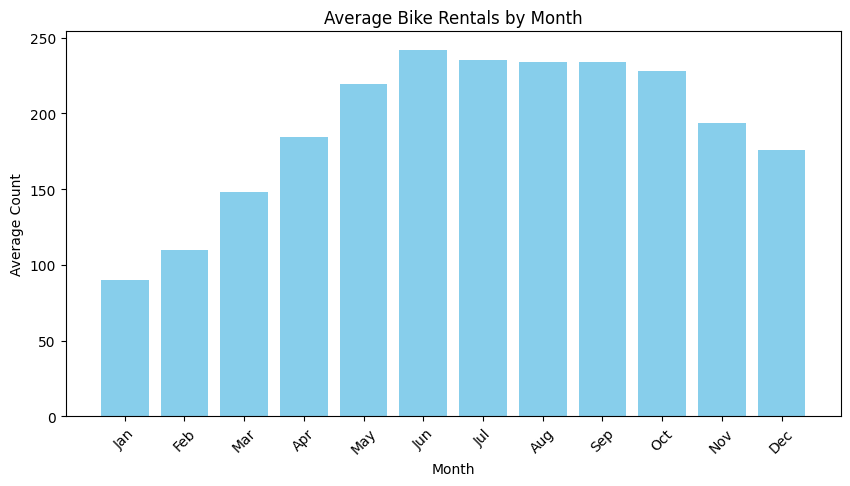

In [22]:
# Extract hour from datetime
df['month'] = df['datetime'].dt.month

# Define custom month bins
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]  # Month ranges: Jan to Dec
labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['month_bin'] = pd.cut(df['month'], bins=bins, labels=labels, include_lowest=True, right=False)


# Calculate average rentals per month bin
avg_rentals = df.groupby('month_bin')[['casual','registered','count']].mean().reset_index()

# Display results
print("Average Rentals by Month:")
print(avg_rentals)

# Visualize the results
plt.figure(figsize=(10, 5))
plt.bar(avg_rentals['month_bin'], avg_rentals['count'], color='skyblue')
plt.title('Average Bike Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.show()

chi square is used when both are categorical.
one-way Anova is used when you want test effect of categorical variable on numerical value.
two-way Anova is used when you want to test two categorical variable on numerical variable.
2 sample T-test to check bike rentals; there is no difference in mean number of bikes on weekdays and weekends.


Value counts for 'day_type':
day_type
Weekday    7412
Weekend    3474
Name: count, dtype: int64

Normality Test (Shapiro-Wilk):
Weekday p-value: 2.252112483001829e-61
Weekend p-value: 4.4728547627905965e-45

Variance Test (Levene):
p-value: 0.9437823280916695

Mann-Whitney U Test:
U-statistic: 12868495.5, p-value: 0.9679139953914079
No significant difference between weekdays and weekends (p >= 0.05)

Independent T-Test:
T-statistic: 1.2096277376026694, p-value: 0.22644804226361348
No significant difference between weekdays and weekends (p >= 0.05)


/Users/lokesh/my_folder/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


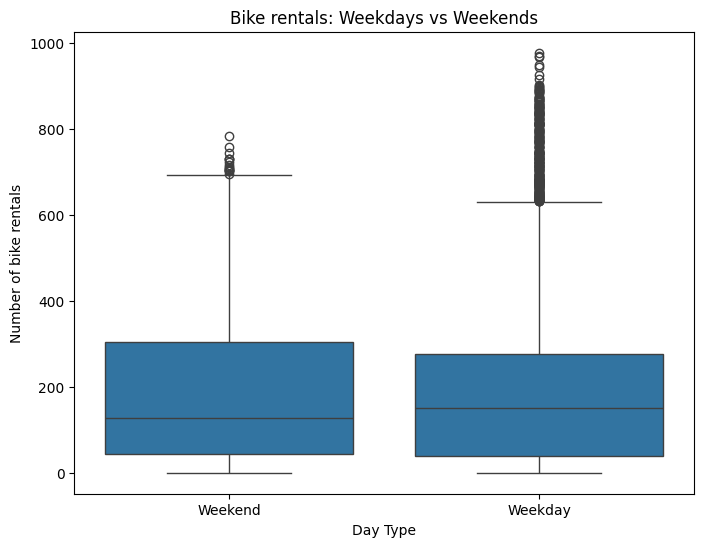

In [23]:
#Hypothesis testing without removing the outliers

# 2. Assign day_type (simplified, since holiday is always 0)
df['day_type'] = df['workingday'].map({1: 'Weekday', 0: 'Weekend'})
# No need for filter, as all rows are Weekday or Weekend

# Verify day_type
print("\nValue counts for 'day_type':")
print(df['day_type'].value_counts())

# 3. Separate data into weekdays and weekends
weekday_counts = df[df['day_type'] == 'Weekday']['count']
weekend_counts = df[df['day_type'] == 'Weekend']['count']

# 4. Check Normality (Shapiro-Wilk Test)
print("\nNormality Test (Shapiro-Wilk):")
print("Weekday p-value:", stats.shapiro(weekday_counts)[1])
print("Weekend p-value:", stats.shapiro(weekend_counts)[1])
# If p-value < 0.05, data is not normal

# 5. Check Equal Variances (Levene's Test)
print("\nVariance Test (Levene):")
print("p-value:", stats.levene(weekday_counts, weekend_counts)[1])
# If p-value < 0.05, variances are unequal

# 6. Perform Mann-Whitney U Test (recommended, non-parametric)
u_stat, p_mannwhitney = stats.mannwhitneyu(weekday_counts, weekend_counts, alternative='two-sided')
print("\nMann-Whitney U Test:")
print(f"U-statistic: {u_stat}, p-value: {p_mannwhitney}")
if p_mannwhitney < 0.05:
    print("Significant difference between weekdays and weekends (p < 0.05)")
else:
    print("No significant difference between weekdays and weekends (p >= 0.05)")

# 7. Perform T-Test (for comparison)
t_stat, p_ttest = stats.ttest_ind(weekday_counts, weekend_counts, equal_var=True)  # Set equal_var=False if variances unequal
print("\nIndependent T-Test:")
print(f"T-statistic: {t_stat}, p-value: {p_ttest}")
if p_ttest < 0.05:
    print("Significant difference between weekdays and weekends (p < 0.05)")
else:
    print("No significant difference between weekdays and weekends (p >= 0.05)")

# 8. Visualize the distributions
plt.figure(figsize=(8,6))
sns.boxplot(x='day_type',y='count',data=df)
plt.title('Bike rentals: Weekdays vs Weekends')
plt.xlabel('Day Type')
plt.ylabel('Number of bike rentals')
plt.show()


Mann-Whitney U Test (without outliers):
U-statistic: 11906775.5, p-value: 0.0037346583612709364
Significant difference (p < 0.05)


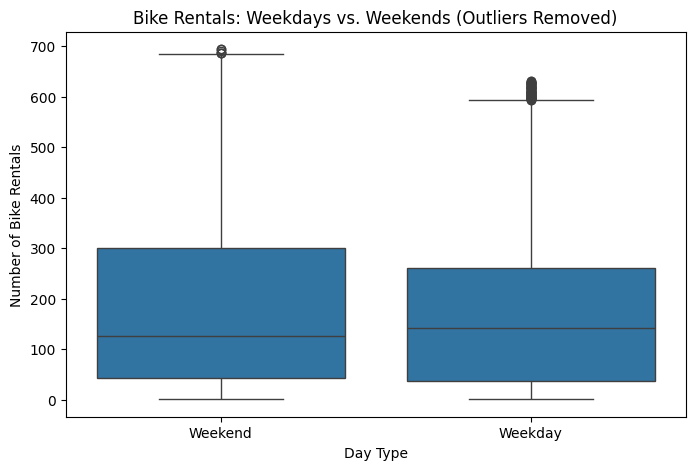

In [24]:
#Conducting Man Whiteny U Test after removing the outliers

# Calculate IQR and outlier bounds for each group
weekday_counts = df[df['day_type'] == 'Weekday']['count']
weekend_counts = df[df['day_type'] == 'Weekend']['count']

# Weekday outliers
q1_weekday = weekday_counts.quantile(0.25)
q3_weekday = weekday_counts.quantile(0.75)
iqr_weekday = q3_weekday - q1_weekday
lower_bound_weekday = q1_weekday - 1.5 * iqr_weekday
upper_bound_weekday = q3_weekday + 1.5 * iqr_weekday

# Weekend outliers
q1_weekend = weekend_counts.quantile(0.25)
q3_weekend = weekend_counts.quantile(0.75)
iqr_weekend = q3_weekend - q1_weekend
lower_bound_weekend = q1_weekend - 1.5 * iqr_weekend
upper_bound_weekend = q3_weekend + 1.5 * iqr_weekend

# Filter out outliers
df_no_outliers = df[
    ((df['day_type'] == 'Weekday') & (df['count'] >= lower_bound_weekday) & (df['count'] <= upper_bound_weekday)) |
    ((df['day_type'] == 'Weekend') & (df['count'] >= lower_bound_weekend) & (df['count'] <= upper_bound_weekend))
]

# Re-run Mann-Whitney U Test
weekday_no_outliers = df_no_outliers[df_no_outliers['day_type'] == 'Weekday']['count']
weekend_no_outliers = df_no_outliers[df_no_outliers['day_type'] == 'Weekend']['count']
u_stat_no_outliers, p_mannwhitney_no_outliers = stats.mannwhitneyu(weekday_no_outliers, weekend_no_outliers, alternative='two-sided')
print("\nMann-Whitney U Test (without outliers):")
print(f"U-statistic: {u_stat_no_outliers}, p-value: {p_mannwhitney_no_outliers}")
if p_mannwhitney_no_outliers < 0.05:
    print("Significant difference (p < 0.05)")
else:
    print("No significant difference (p >= 0.05)")

# Re-plot without outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_type', y='count', data=df_no_outliers)
plt.title('Bike Rentals: Weekdays vs. Weekends (Outliers Removed)')
plt.xlabel('Day Type')
plt.ylabel('Number of Bike Rentals')
plt.show()

Without removing the outliers the null hypothesis can't be rejected and states true that there is NO significant difference between number of bike rentals on weekends and weekdays ; but after removing the outliers the Null hypothesis is rejected. Thus removing the outliers is a necessary step to find the actual results.

In [21]:
df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

Since 4 has only 1 count, it can be problematic to conduce statistical test on this condition.

Weather condition value counts:
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

After excluding weather condition 4:
weather
1    7192
2    2834
3     859
Name: count, dtype: int64

Normality Test (Shapiro-Wilk):
Weather 1 p-value: 1.5964921477007922e-57
Weather 2 p-value: 9.777839106113603e-43
Weather 3 p-value: 3.875893017395983e-33

Variance Test (Levene):
p-value: 6.198278710731511e-36

Kruskal-Wallis Test:
Statistic: 204.95566833068537, p-value: 3.122066178659941e-45
Significant difference in bike rentals across weather conditions (p < 0.05)

ANOVA Test:
Statistic: 98.28356881946706, p-value: 4.976448509904196e-43
Significant difference in bike rentals across weather conditions (p < 0.05)


/Users/lokesh/my_folder/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)


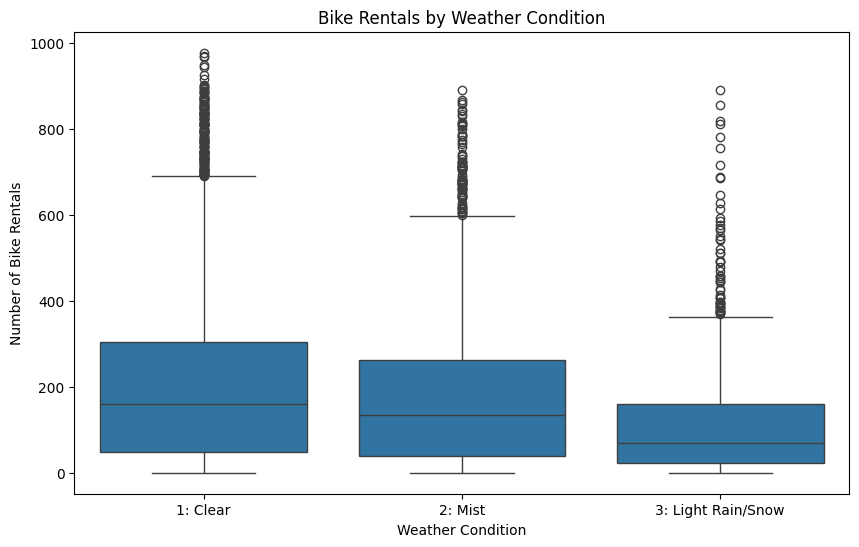

In [25]:
# Assuming df has 'weather' and 'count' columns

# 1. Check value counts (already provided)
print("Weather condition value counts:")
print(df['weather'].value_counts())

# 2. Exclude weather condition 4 (only 1 instance)
df = df[df['weather'] != 4]
print("\nAfter excluding weather condition 4:")
print(df['weather'].value_counts())

# 3. Group bike rental counts by weather condition
weather_1 = df[df['weather'] == 1]['count']
weather_2 = df[df['weather'] == 2]['count']
weather_3 = df[df['weather'] == 3]['count']

# 4. Check Normality (Shapiro-Wilk Test) for each group
print("\nNormality Test (Shapiro-Wilk):")
print("Weather 1 p-value:", stats.shapiro(weather_1)[1])
print("Weather 2 p-value:", stats.shapiro(weather_2)[1])
print("Weather 3 p-value:", stats.shapiro(weather_3)[1])
# If p-value < 0.05, data is not normal

# 5. Check Equal Variances (Levene's Test)
print("\nVariance Test (Levene):")
print("p-value:", stats.levene(weather_1, weather_2, weather_3)[1])
# If p-value < 0.05, variances are unequal

# 6. Perform Kruskal-Wallis Test (recommended, non-parametric)
kruskal_stat, p_kruskal = stats.kruskal(weather_1, weather_2, weather_3)
print("\nKruskal-Wallis Test:")
print(f"Statistic: {kruskal_stat}, p-value: {p_kruskal}")
if p_kruskal < 0.05:
    print("Significant difference in bike rentals across weather conditions (p < 0.05)")
else:
    print("No significant difference in bike rentals across weather conditions (p >= 0.05)")

# 7. Perform ANOVA (parametric, for comparison)
anova_stat, p_anova = stats.f_oneway(weather_1, weather_2, weather_3)
print("\nANOVA Test:")
print(f"Statistic: {anova_stat}, p-value: {p_anova}")
if p_anova < 0.05:
    print("Significant difference in bike rentals across weather conditions (p < 0.05)")
else:
    print("No significant difference in bike rentals across weather conditions (p >= 0.05)")

# 8. Visualize the distributions
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather', y='count', data=df)
plt.title('Bike Rentals by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Bike Rentals')
plt.xticks(ticks=[0, 1, 2], labels=['1: Clear', '2: Mist', '3: Light Rain/Snow'])
plt.show()

We reject the null hypothesis since there is statistical difference in different weather conditions on the number of bike rentals.

In [26]:
print("Different season value:")
df['season'].value_counts()

Different season value:


season
4    2734
2    2733
3    2733
1    2685
Name: count, dtype: int64

Season value counts:
season
2    2685
4    2638
3    2637
1    2614
Name: count, dtype: int64

Normality Test (Shapiro-Wilk):
Season 1 (Spring) p-value: 3.434796588977624e-48
Season 2 (Summer) p-value: 1.1883801158787e-38
Season 3 (Fall) p-value: 1.821269098471776e-36
Season 4 (Winter) p-value: 1.8080211549043292e-39

Variance Test (Levene):
p-value: 9.284234177352675e-111

Kruskal-Wallis Test:
Statistic: 664.3115002424656, p-value: 1.1491290884322014e-143
Significant difference in bike rentals across seasons (p < 0.05)

ANOVA Test:
Statistic: 224.14778226233102, p-value: 5.501963212599181e-141
Significant difference in bike rentals across seasons (p < 0.05)


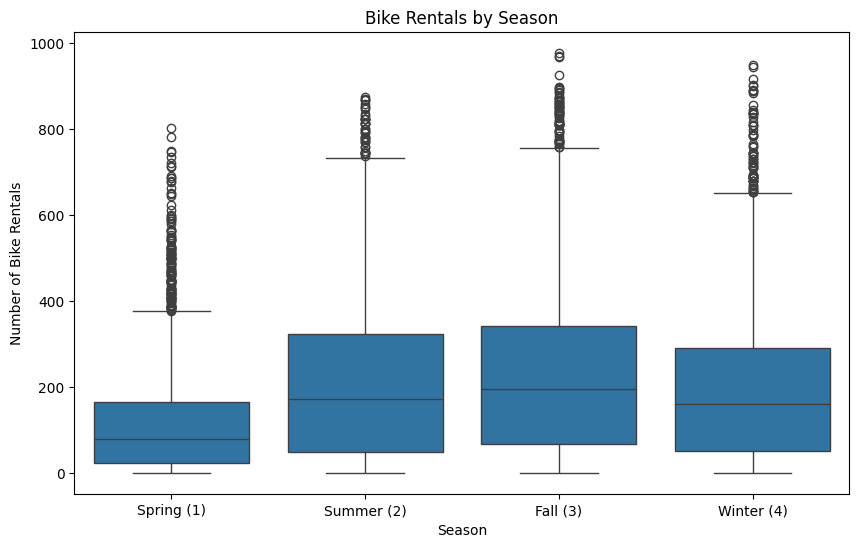

In [91]:
# Assuming df has 'season' and 'count' columns

# 1. Check value counts (already provided)
print("Season value counts:")
print(df['season'].value_counts())

# 2. Group bike rental counts by season
season_1 = df[df['season'] == 1]['count']  # Spring
season_2 = df[df['season'] == 2]['count']  # Summer
season_3 = df[df['season'] == 3]['count']  # Fall
season_4 = df[df['season'] == 4]['count']  # Winter

# 3. Check Normality (Shapiro-Wilk Test) for each group
print("\nNormality Test (Shapiro-Wilk):")
print("Season 1 (Spring) p-value:", stats.shapiro(season_1)[1])
print("Season 2 (Summer) p-value:", stats.shapiro(season_2)[1])
print("Season 3 (Fall) p-value:", stats.shapiro(season_3)[1])
print("Season 4 (Winter) p-value:", stats.shapiro(season_4)[1])
# If p-value < 0.05, data is not normal

# 4. Check Equal Variances (Levene's Test)
print("\nVariance Test (Levene):")
print("p-value:", stats.levene(season_1, season_2, season_3, season_4)[1])
# If p-value < 0.05, variances are unequal

# 5. Perform Kruskal-Wallis Test (recommended, non-parametric)
kruskal_stat, p_kruskal = stats.kruskal(season_1, season_2, season_3, season_4)
print("\nKruskal-Wallis Test:")
print(f"Statistic: {kruskal_stat}, p-value: {p_kruskal}")
if p_kruskal < 0.05:
    print("Significant difference in bike rentals across seasons (p < 0.05)")
else:
    print("No significant difference in bike rentals across seasons (p >= 0.05)")

# 6. Perform ANOVA (parametric, for comparison)
anova_stat, p_anova = stats.f_oneway(season_1, season_2, season_3, season_4)
print("\nANOVA Test:")
print(f"Statistic: {anova_stat}, p-value: {p_anova}")
if p_anova < 0.05:
    print("Significant difference in bike rentals across seasons (p < 0.05)")
else:
    print("No significant difference in bike rentals across seasons (p >= 0.05)")

# 7. Visualize the distributions
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='count', data=df)
plt.title('Bike Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Number of Bike Rentals')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Spring (1)', 'Summer (2)', 'Fall (3)', 'Winter (4)'])
plt.show()

Kruskal-Wallis Test is less sensitive to the shape of the distribution (e.g., skewness) and more focused on the relative order. This means that bike rentals (count) are not distributed the same way in all seasons—at least one season differs significantly from the others.

In [33]:


# Create a figure with three subplots for boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Boxplot 1: Weekdays vs. Weekends
sns.boxplot(x='day_type', y='count', data=df, ax=axes[0])
axes[0].set_title('Bike Rentals: Weekdays vs. Weekends')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Number of Bike Rentals')

# Boxplot 2: Seasons
sns.boxplot(x='season', y='count', data=df, ax=axes[1])
axes[1].set_title('Bike Rentals by Season')
axes[1].set_xlabel('Season')
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(['Spring (1)', 'Summer (2)', 'Fall (3)', 'Winter (4)'])
axes[1].set_ylabel('')

# Boxplot 3: Weather Conditions
# Exclude weather condition 4 (only 1 instance)
df_weather = df[df['weather'] != 4]
sns.boxplot(x='weather', y='count', data=df_weather, ax=axes[2])
axes[2].set_title('Bike Rentals by Weather Condition')
axes[2].set_xlabel('Weather Condition')
axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(['Clear (1)', 'Mist (2)', 'Rain/Snow (3)'])
axes[2].set_ylabel('')




Summary Table:
   Category      Group  Median         IQR Outlier Range
0  Day Type    Weekday   151.0  41.0-277.0     Up to 977
1  Day Type    Weekend   128.0  44.0-304.0     Up to 783
2    Season   Season 1    78.0  24.0-164.0     Up to 801
3    Season   Season 2   172.0  49.0-321.0     Up to 873
4    Season   Season 3   195.0  68.0-347.0     Up to 977
5    Season   Season 4   161.0  51.0-294.0     Up to 948
6   Weather  Weather 1   161.0  48.0-305.0     Up to 977
7   Weather  Weather 2   134.0  41.0-264.0     Up to 890
8   Weather  Weather 3    71.0  23.0-161.0     Up to 891


In [34]:
# Generate a summary table
summary_table = {
    'Category': [],
    'Group': [],
    'Median': [],
    'IQR': [],
    'Outlier Range': []
}

# Weekdays vs. Weekends
for day_type in ['Weekday', 'Weekend']:
    data = df[df['day_type'] == day_type]['count']
    median = data.median()
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = f"{q1}-{q3}"
    upper_bound = q3 + 1.5 * (q3 - q1)
    outlier_range = f"Up to {data[data > upper_bound].max() if (data > upper_bound).any() else 'None'}"
    summary_table['Category'].append('Day Type')
    summary_table['Group'].append(day_type)
    summary_table['Median'].append(median)
    summary_table['IQR'].append(iqr)
    summary_table['Outlier Range'].append(outlier_range)

# Seasons
for season in [1, 2, 3, 4]:
    data = df[df['season'] == season]['count']
    median = data.median()
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = f"{q1}-{q3}"
    upper_bound = q3 + 1.5 * (q3 - q1)
    outlier_range = f"Up to {data[data > upper_bound].max() if (data > upper_bound).any() else 'None'}"
    summary_table['Category'].append('Season')
    summary_table['Group'].append(f"Season {season}")
    summary_table['Median'].append(median)
    summary_table['IQR'].append(iqr)
    summary_table['Outlier Range'].append(outlier_range)

# Weather Conditions
for weather in [1, 2, 3]:
    data = df_weather[df_weather['weather'] == weather]['count']
    median = data.median()
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = f"{q1}-{q3}"
    upper_bound = q3 + 1.5 * (q3 - q1)
    outlier_range = f"Up to {data[data > upper_bound].max() if (data > upper_bound).any() else 'None'}"
    summary_table['Category'].append('Weather')
    summary_table['Group'].append(f"Weather {weather}")
    summary_table['Median'].append(median)
    summary_table['IQR'].append(iqr)
    summary_table['Outlier Range'].append(outlier_range)

# Convert to DataFrame and save
summary_df = pd.DataFrame(summary_table)
print("\nSummary Table:")
print(summary_df)
summary_df.to_csv('bike_rental_summary.csv', index=False)


Summary Table:
   Category      Group  Median         IQR Outlier Range
0  Day Type    Weekday   151.0  41.0-277.0     Up to 977
1  Day Type    Weekend   128.0  44.0-304.0     Up to 783
2    Season   Season 1    78.0  24.0-164.0     Up to 801
3    Season   Season 2   172.0  49.0-321.0     Up to 873
4    Season   Season 3   195.0  68.0-347.0     Up to 977
5    Season   Season 4   161.0  51.0-294.0     Up to 948
6   Weather  Weather 1   161.0  48.0-305.0     Up to 977
7   Weather  Weather 2   134.0  41.0-264.0     Up to 890
8   Weather  Weather 3    71.0  23.0-161.0     Up to 891


Few Recommendations:

Seasons: Allocate 30–50% more bikes in Fall (median 195.0, IQR 68.0–347.0) and Summer (172.0, 49.0–321.0) compared to Spring (78.0, 24.0–164.0). Winter (161.0) has moderate demand but high variability (IQR 51.0–294.0), so maintain slightly more bikes than Spring.

Weather: Prioritize Clear weather (median 161.0, IQR 48.0–305.0) with 40–50% more bikes than Rain/Snow (71.0, 23.0–161.0). Mist (134.0, 41.0–264.0) requires a moderate increase (~20–30% more than Rain/Snow).

Day Type: The table shows that weekdays have a higher daily median (151.0 vs. 128.0), reflecting consistent demand across more days, but the boxplot indicates that weekends have higher peak hourly demand (median ~300–350 vs. ~250–300) with greater variability (IQR ~250–450 vs. ~200–400). Increase inventory by 20–30% on weekends to accommodate peak hourly demand, while maintaining sufficient weekday inventory to support steady daily usage.